In [1]:
import os

In [2]:
%env LD_LIBRARY_PATH="/usr/lib/cuda:/home/amos/sources/TensorRT-8.6.1.6/targets/x86_64-linux-gnu/lib"

env: LD_LIBRARY_PATH="/usr/lib/cuda:/home/amos/sources/TensorRT-8.6.1.6/targets/x86_64-linux-gnu/lib"


In [3]:
os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ["LD_LIBRARY_PATH"]

'"/usr/lib/cuda:/home/amos/sources/TensorRT-8.6.1.6/targets/x86_64-linux-gnu/lib"'

In [4]:
import time 
import shutil 
from pathlib import Path 

import cv2
import IPython
import numpy as np
import pandas as pd
import tensorflow as tf
import sqlalchemy as db
from tqdm import tqdm 
from tensorflow.python.compiler.tensorrt import trt_convert as trt

from videotools.models.RetinaFaceKeras.RetinaFace import build_model as tf_model
from videotools.models.RetinaFaceKeras.preprocess import preprocess_image
from videotools.detectors import RetinaFaceBatch

2024-06-29 15:38:51.251712: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [5]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [6]:
def draw_faces(image, faces):
    for _, face in faces.items():
        # バウンディングボックス
        x1, y1, x2, y2 = face['facial_area']
        color = (0, 0, 255)
        thickness = 2
        cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness, cv2.LINE_AA)
    show_image(image)

In [7]:
def build_model():
        """
        Builds retinaface model once and store it into memory
        """
        # pylint: disable=invalid-name
        global model  # singleton design pattern

        if not "model" in globals():
            model = tf.function(
                tf_model(),
                input_signature=(tf.TensorSpec(shape=[None, None, None, 3], dtype=np.float16),),
            )

        return model

Before converting the model, we first have to save it to disk.

In [8]:
model = tf_model()

2024-06-29 15:38:54.546931: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-06-29 15:38:54.551842: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-06-29 15:38:54.551985: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [9]:
# model.save('/home/amos/programs/CineFace/research/data/retina')

## Converting to FP16

In [12]:
def input_fnc():
    input_sizes = \
        [[1, 720, 1280, 3]]
                 
    for input_size in input_sizes:
        input_data = np.random.rand(*input_size).astype(np.float32)
        yield input_data

In [13]:
# Instantiate the TF-TRT converter
converter = trt.TrtGraphConverterV2(
   input_saved_model_dir='/home/amos/programs/CineFace/research/data/retina',
   precision_mode=trt.TrtPrecisionMode.FP16,
   allow_build_at_runtime=True,
   minimum_segment_size=3,
   maximum_cached_engines=100,
   use_calibration=False
)

INFO:tensorflow:Linked TensorRT version: (8, 6, 1)
INFO:tensorflow:Loaded TensorRT version: (8, 6, 1)


In [14]:
converter.convert()
converter.build(input_fnc)

2024-06-27 15:40:32.205999: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-06-27 15:40:32.206110: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2024-06-27 15:40:32.206209: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2024-06-27 15:40:32.206506: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-06-27 15:40:32.206628: I external/local_xla/xla/stream_executor/cuda/cuda_e

INFO:tensorflow:Clearing prior device assignments in loaded saved model


2024-06-27 15:40:34.872898: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-06-27 15:40:34.873007: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2024-06-27 15:40:34.873067: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2024-06-27 15:40:34.873269: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-06-27 15:40:34.873384: I external/local_xla/xla/stream_executor/cuda/cuda_e

In [15]:
model_dir = '/home/amos/programs/CineFace/research/data/retina_converted'
if Path(model_dir).exists:
    shutil.rmtree(model_dir)
Path.mkdir(Path('/home/amos/programs/CineFace/research/data/retina_converted'))
converter.save('/home/amos/programs/CineFace/research/data/retina_converted')

INFO:tensorflow:Assets written to: /home/amos/programs/CineFace/research/data/retina_converted/assets


INFO:tensorflow:Assets written to: /home/amos/programs/CineFace/research/data/retina_converted/assets


## Convert to INT8

Unlike with FP32 or FP16, converting to INT8 requires calibration. RetinaFace is based on ResNet50, which was trained on the ImageNet dataset. Therefore, we need to load data from ImageNet to use in calibration when converting the model.

In [10]:
files = [x for x in Path('/home/amos/datasets/imagenet/tiny-imagenet-200/val/images/').iterdir()]
print(len(files))

10000


In [11]:
x_test = np.array([tf.convert_to_tensor(cv2.imread(str(x)), dtype=tf.dtypes.float32) for x in tqdm(files[:100])])

100%|██████████| 100/100 [00:00<00:00, 108.11it/s]


In [12]:
x_test.shape

(100, 64, 64, 3)

After loading the data, we need to write a function to pass as an argument during conversion. 

In [13]:
BATCH_SIZE = 10
NUM_CALIB_BATCHES = 10
def calibration_input_fn():
    for i in range(NUM_CALIB_BATCHES):
        start_idx = i * BATCH_SIZE
        end_idx = (i + 1) * BATCH_SIZE
        x = x_test[start_idx:end_idx, :]
        yield [x]

In [14]:
# Instantiate the TF-TRT converter
int8_converter = trt.TrtGraphConverterV2(
   input_saved_model_dir='/home/amos/programs/CineFace/research/data/retina',
   precision_mode=trt.TrtPrecisionMode.INT8,
   allow_build_at_runtime=True,
   minimum_segment_size=3,
   maximum_cached_engines=100,
   use_calibration=True
)

INFO:tensorflow:Linked TensorRT version: (8, 6, 1)
INFO:tensorflow:Loaded TensorRT version: (8, 6, 1)


In [15]:
# Convert the model with valid calibration data
int8_func = int8_converter.convert(calibration_input_fn=calibration_input_fn)

2024-06-29 15:39:15.816220: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-06-29 15:39:15.816341: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2024-06-29 15:39:15.816428: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2024-06-29 15:39:15.816758: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-06-29 15:39:15.816872: I external/local_xla/xla/stream_executor/cuda/cuda_e

INFO:tensorflow:Clearing prior device assignments in loaded saved model


2024-06-29 15:39:18.274705: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-06-29 15:39:18.274835: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2024-06-29 15:39:18.274929: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2024-06-29 15:39:18.275271: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-06-29 15:39:18.275387: I external/local_xla/xla/stream_executor/cuda/cuda_e

: 

In [ ]:
# Input for dynamic shapes profile generation
MAX_BATCH_SIZE=128
def input_fn():
   batch_size = MAX_BATCH_SIZE
   x = x_test[0:batch_size, :]
   yield [x]

In [ ]:
# Build the engine
converter.build(input_fn=input_fn)

NameError: name 'converter' is not defined

In [ ]:
converter.save('../data/retina_int8')

## Testing the Converted Model

In [14]:
converted_model = tf.saved_model.load('../data/retina_converted')
print(list(converted_model.signatures.keys()))  # ["serving_default"]

['serving_default']


2024-06-26 21:11:39.449819: E tensorflow/compiler/tf2tensorrt/utils/trt_logger.cc:87] DefaultLogger 3: [runtime.cpp::~Runtime::346] Error Code 3: API Usage Error (Parameter check failed at: runtime/rt/runtime.cpp::~Runtime::346, condition: mEngineCounter.use_count() == 1. Destroying a runtime before destroying deserialized engines created by the runtime leads to undefined behavior.
)
2024-06-26 21:11:39.469577: E tensorflow/compiler/tf2tensorrt/utils/trt_logger.cc:87] DefaultLogger 3: [runtime.cpp::~Runtime::346] Error Code 3: API Usage Error (Parameter check failed at: runtime/rt/runtime.cpp::~Runtime::346, condition: mEngineCounter.use_count() == 1. Destroying a runtime before destroying deserialized engines created by the runtime leads to undefined behavior.
)
2024-06-26 21:11:39.488765: E tensorflow/compiler/tf2tensorrt/utils/trt_logger.cc:87] DefaultLogger 3: [runtime.cpp::~Runtime::346] Error Code 3: API Usage Error (Parameter check failed at: runtime/rt/runtime.cpp::~Runtime::34

In [15]:
infer = converted_model.signatures['serving_default']
print(infer.structured_outputs)

{'output_2': TensorSpec(shape=(None, None, None, 8), dtype=tf.float32, name='output_2'), 'output_4': TensorSpec(shape=(None, None, None, 20), dtype=tf.float32, name='output_4'), 'output_3': TensorSpec(shape=(None, None, None, 20), dtype=tf.float32, name='output_3'), 'output_1': TensorSpec(shape=(None, None, None, 8), dtype=tf.float32, name='output_1'), 'output_6': TensorSpec(shape=(None, None, None, 4), dtype=tf.float32, name='output_6'), 'output_7': TensorSpec(shape=(None, None, None, 4), dtype=tf.float32, name='output_7'), 'output_8': TensorSpec(shape=(None, None, None, 4), dtype=tf.float32, name='output_8'), 'output_0': TensorSpec(shape=(None, None, None, 8), dtype=tf.float32, name='output_0'), 'output_5': TensorSpec(shape=(None, None, None, 20), dtype=tf.float32, name='output_5')}


In [12]:
img = cv2.imread('./images/img_1.jpg')
im_tensor, im_info, im_scale = preprocess_image(img, False)
tensor = tf.convert_to_tensor(im_tensor, dtype=tf.dtypes.float32)
tensor.shape

TensorShape([1, 566, 736, 3])

In [15]:
t = time.time()
out_converted = infer(tensor)
print(time.time() - t)
out_converted = list(sorted([v.numpy() for v in out_converted.values()], key=lambda x: x.shape))

2024-06-26 16:42:15.813001: I tensorflow/compiler/tf2tensorrt/common/utils.cc:106] Linked TensorRT version: 8.6.1
2024-06-26 16:42:15.813030: I tensorflow/compiler/tf2tensorrt/common/utils.cc:108] Loaded TensorRT version: 8.6.1
2024-06-26 16:42:20.584519: I tensorflow/compiler/tf2tensorrt/convert/convert_nodes.cc:1329] [TF-TRT] Sparse compute capability: enabled.
2024-06-26 16:44:01.075757: W tensorflow/compiler/tf2tensorrt/utils/trt_logger.cc:83] TF-TRT Warning: DefaultLogger TensorRT encountered issues when converting weights between types and that could affect accuracy.
2024-06-26 16:44:01.075782: W tensorflow/compiler/tf2tensorrt/utils/trt_logger.cc:83] TF-TRT Warning: DefaultLogger Check verbose logs for the list of affected weights.
2024-06-26 16:44:01.075788: W tensorflow/compiler/tf2tensorrt/utils/trt_logger.cc:83] TF-TRT Warning: DefaultLogger - 71 weights are affected by this issue: Detected subnormal FP16 values.
2024-06-26 16:44:01.075877: W tensorflow/compiler/tf2tensorrt/

196.19525742530823


2024-06-26 16:45:30.653373: W tensorflow/compiler/tf2tensorrt/utils/trt_logger.cc:83] TF-TRT Warning: DefaultLogger TensorRT encountered issues when converting weights between types and that could affect accuracy.
2024-06-26 16:45:30.653396: W tensorflow/compiler/tf2tensorrt/utils/trt_logger.cc:83] TF-TRT Warning: DefaultLogger Check verbose logs for the list of affected weights.
2024-06-26 16:45:30.653403: W tensorflow/compiler/tf2tensorrt/utils/trt_logger.cc:83] TF-TRT Warning: DefaultLogger - 7 weights are affected by this issue: Detected subnormal FP16 values.
2024-06-26 16:45:30.653423: W tensorflow/compiler/tf2tensorrt/utils/trt_logger.cc:83] TF-TRT Warning: DefaultLogger - 3 weights are affected by this issue: Detected values less than smallest positive FP16 subnormal value and converted them to the FP16 minimum subnormalized value.


In [53]:
t = time.time()
out = model(tensor)
print(time.time() - t)
out = [x.numpy() for x in out]

2024-06-25 21:36:18.878579: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8902


0.908607006072998


In [54]:
det = RetinaFaceBatch()

In [55]:
predictions = det.parse_predictions(out, im_info, 1)
predictions

{'face_1': {'score': 0.9994006156921387,
  'facial_area': [190, 49, 563, 542],
  'landmarks': {'right_eye': [284.9718, 229.25107],
   'left_eye': [460.28156, 229.2971],
   'nose': [366.36136, 322.01297],
   'mouth_right': [304.4282, 423.03052],
   'mouth_left': [434.19052, 423.12097]}}}

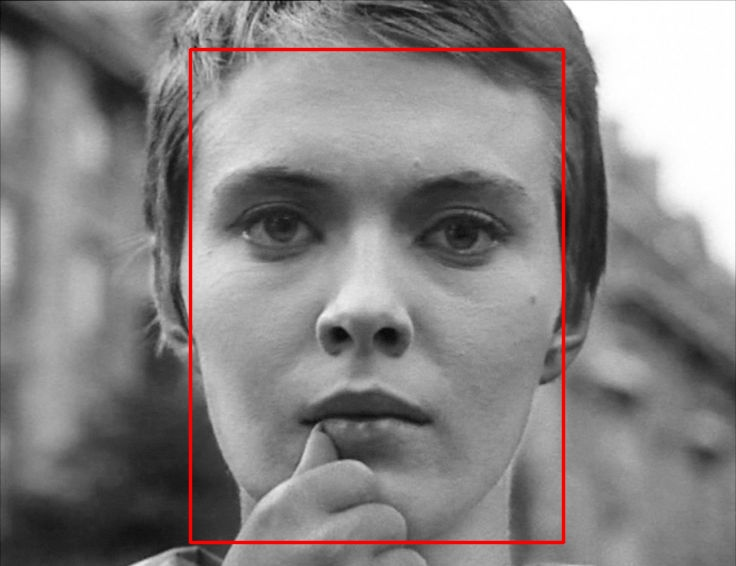

In [56]:
draw_faces(img, predictions)

In [57]:
converted_predictions = det.parse_predictions(out_converted, im_info, 1)
converted_predictions

{'face_1': {'score': 0.9994006156921387,
  'facial_area': [190, 49, 563, 542],
  'landmarks': {'right_eye': [284.97183, 229.24995],
   'left_eye': [460.2834, 229.29779],
   'nose': [366.36182, 322.01004],
   'mouth_right': [304.4278, 423.03064],
   'mouth_left': [434.1927, 423.12262]}}}

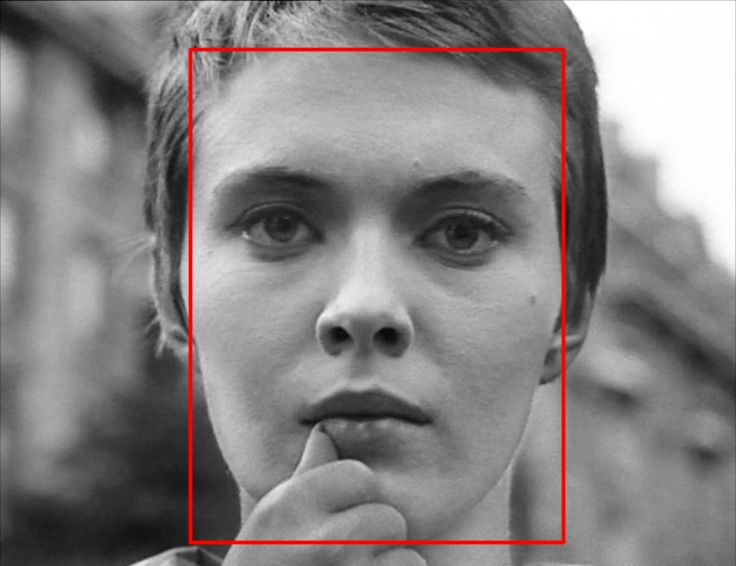

In [58]:
draw_faces(img, converted_predictions)

### Getting Input Shapes

In [13]:
username = 'amos'
password = 'M0$hicat'
host = '192.168.0.131'
port = '3306'
database = 'CineFace'

In [15]:
connection_string = f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}'
engine = db.create_engine(connection_string)

In [25]:
with engine.connect() as conn:
    df = pd.read_sql_query("""
                           SELECT
                                width, 
                                height
                           FROM queue
                           GROUP BY width, height
                           """, conn)
df.head()

,width,height
0,3840,2160
1,1920,1080
2,1440,1080
3,1436,1080
4,1432,1080


In [43]:
a = [(x.height, x.width, 3) for x in df.itertuples()]

In [44]:
[x for x in a]

[(2160, 3840, 3),
 (1080, 1920, 3),
 (1080, 1440, 3),
 (1080, 1436, 3),
 (1080, 1432, 3),
 (1080, 1434, 3),
 (1080, 1444, 3),
 (1072, 1912, 3),
 (1076, 1916, 3),
 (1080, 1448, 3),
 (1920, 3840, 3),
 (960, 1920, 3),
 (958, 1920, 3),
 (1080, 1916, 3),
 (1080, 1918, 3),
 (1916, 3840, 3),
 (1906, 3838, 3),
 (1080, 1438, 3),
 (1078, 1438, 3),
 (1076, 1438, 3),
 (1078, 1436, 3),
 (1076, 1440, 3),
 (1078, 1440, 3),
 (1076, 1432, 3),
 (480, 718, 3),
 (480, 716, 3),
 (480, 710, 3),
 (480, 708, 3),
 (480, 706, 3),
 (480, 720, 3),
 (480, 540, 3),
 (872, 1920, 3),
 (720, 1280, 3),
 (1608, 3840, 3),
 (1606, 3840, 3),
 (804, 1920, 3),
 (800, 1920, 3),
 (1600, 3840, 3),
 (576, 1024, 3),
 (1080, 1472, 3),
 (1080, 1464, 3),
 (1080, 1770, 3),
 (1078, 1920, 3),
 (1078, 1918, 3),
 (1072, 1916, 3),
 (1076, 1920, 3),
 (1080, 1914, 3),
 (1074, 1918, 3),
 (480, 640, 3)]